In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcdefaults()
plt.style.use('seaborn-v0_8-paper')
plt.rc('font', **{'family': 'sans-serif', 'sans-serif': ['Helvetica']})

from ttcrpy.rgrid import Grid2d

# Example 6 - qSV triplication in a VTI medium

In a transversely isotropic medium the shear wave polarized in the vertical plane
(qSV) can have a **multivalued** wavefront: over a range of directions three
arrivals leave the source along three different raypaths.  The wavefront folds
back on itself and shows two cusps.  This is the *triplication* described in
Thomsen (1986) and at length in Tsvankin (2012).

This notebook builds such a medium, looks at where the triplication comes from,
and then asks what `ttcrpy` — a **first-arrival** solver — actually returns for
it.  The answer is more interesting than it first appears, and is worth
understanding before using `aniso='vti_psv'` with `set_phase('qSV')` on a
strongly anelliptic model.

The medium is described by the two vertical velocities and Thomsen's parameters,
and how far it is from elliptical is measured by

$$\sigma = \left(\frac{V_{P0}}{V_{S0}}\right)^2 (\epsilon - \delta)$$

An elliptical medium has $\epsilon = \delta$, so $\sigma = 0$ and the qSV
wavefront is a circle.  The triplication appears once $\sigma$ is large enough.

In [2]:
Vp0, Vs0, eps, dlt = 3.0, 1.5, 0.2, -0.2      # km/s, km/s, -, -

sigma = (Vp0/Vs0)**2 * (eps - dlt)
print('sigma = {0:.2f}'.format(sigma))


def phase_velocity(theta, sign):
    """Exact VTI phase velocity, as ttcr computes it in Cell.h.

    sign = +1 gives qP, sign = -1 gives qSV.  No weak-anisotropy approximation
    is made: this is the exact solution of the Christoffel equation.
    """
    f = 1.0 - Vs0**2 / Vp0**2
    s = np.sin(theta)**2
    A = 1.0 + 2.0*eps*s/f
    R = np.maximum(A*A - 8.0*(eps - dlt)*s*(1.0 - s)/f, 0.0)
    G = 1.0 + eps*s - f/2.0 + sign*(f/2.0)*np.sqrt(R)
    return Vp0 * np.sqrt(np.maximum(G, 0.0))

sigma = 1.60


### 6.1 Phase velocity

The phase velocity is the speed of a plane wave whose normal makes an angle
$\theta$ with the symmetry axis.  It is single valued and perfectly smooth, and
gives no hint that anything unusual is about to happen.

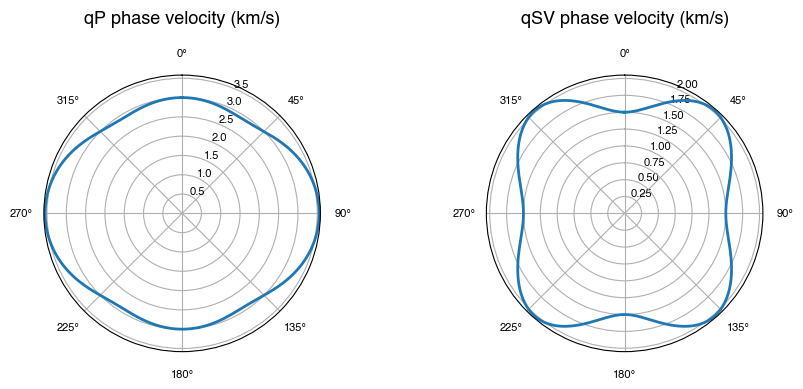

In [3]:
theta = np.linspace(0.0, 2.0*np.pi, 2001)

fig, ax = plt.subplots(1, 2, figsize=(9, 4), subplot_kw={'projection': 'polar'})
for a, sign, name in zip(ax, (1.0, -1.0), ('qP', 'qSV')):
    v = phase_velocity(theta, sign)
    a.plot(theta, v, lw=2)
    a.set_theta_zero_location('N')
    a.set_theta_direction(-1)
    a.set_title('{0} phase velocity (km/s)'.format(name), fontsize=13, pad=18)
plt.tight_layout()
plt.show()

### 6.2 Group velocity, and where the triplication comes from

Energy does not travel along the phase normal.  The group (or energy) velocity
is obtained from the phase velocity and its derivative,

$$V_{g,x} = v\sin\theta + \frac{dv}{d\theta}\cos\theta, \qquad
  V_{g,z} = v\cos\theta - \frac{dv}{d\theta}\sin\theta$$

and the direction it points in, the **ray angle** $\psi$, is not $\theta$.
Sweeping $\theta$ from $0$ to $90^\circ$ traces the wavefront.  For the qP wave
$\psi$ increases with $\theta$ and the wavefront is a simple convex curve.  For
qSV in this medium $\psi$ **decreases** over part of the range: the wavefront
turns back on itself, and three values of $\theta$ share the same ray angle.

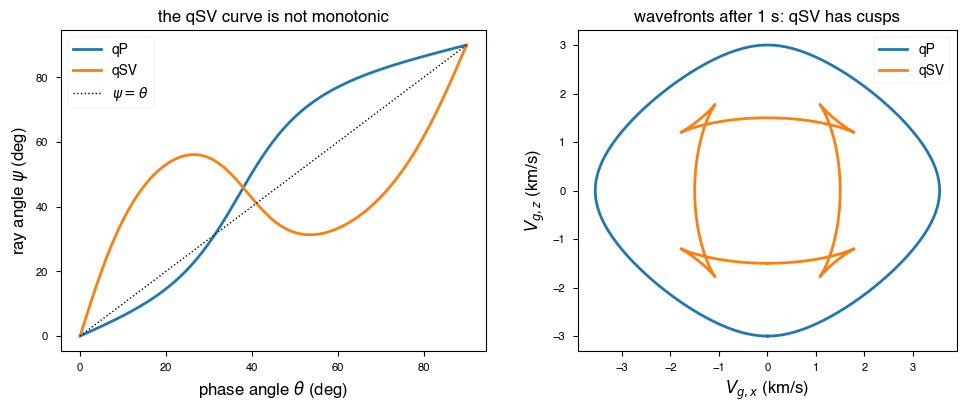

In [4]:
def group_velocity(sign, n=200001):
    th = np.linspace(-np.pi, np.pi, n)
    v = phase_velocity(th, sign)
    dv = np.gradient(v, th)
    gx = v*np.sin(th) + dv*np.cos(th)
    gz = v*np.cos(th) - dv*np.sin(th)
    return th, gx, gz, np.hypot(gx, gz), np.arctan2(gx, gz)


th_p, gxp, gzp, Vgp, psip = group_velocity(1.0)
th_s, gxs, gzs, Vgs, psis = group_velocity(-1.0)

fig, ax = plt.subplots(1, 2, figsize=(10, 4.2))

ax[0].plot(np.degrees(th_p[th_p >= 0][:50001]),
           np.degrees(psip[th_p >= 0][:50001]), lw=2, label='qP')
ax[0].plot(np.degrees(th_s[th_s >= 0][:50001]),
           np.degrees(psis[th_s >= 0][:50001]), lw=2, label='qSV')
ax[0].plot([0, 90], [0, 90], 'k:', lw=1, label=r'$\psi=\theta$')
ax[0].set_xlabel(r'phase angle $\theta$ (deg)', fontsize=12)
ax[0].set_ylabel(r'ray angle $\psi$ (deg)', fontsize=12)
ax[0].set_title('the qSV curve is not monotonic', fontsize=12)
ax[0].legend(fontsize=10)

ax[1].plot(gxp, gzp, lw=2, label='qP')
ax[1].plot(gxs, gzs, lw=2, label='qSV')
ax[1].set_xlabel('$V_{g,x}$ (km/s)', fontsize=12)
ax[1].set_ylabel('$V_{g,z}$ (km/s)', fontsize=12)
ax[1].set_title('wavefronts after 1 s: qSV has cusps', fontsize=12)
ax[1].set_aspect('equal')
ax[1].legend(fontsize=10)
plt.tight_layout()
plt.show()

In [5]:
# the window of ray angles over which the qSV wavefront is multivalued
d = np.diff(psis[(th_s >= 0) & (th_s <= np.pi/2)])
folded = np.where(d < 0)[0]
lo = np.degrees(psis[(th_s >= 0) & (th_s <= np.pi/2)][folded].min())
hi = np.degrees(psis[(th_s >= 0) & (th_s <= np.pi/2)][folded].max())
print('qSV is multivalued for ray angles between '
      '{0:.0f} and {1:.0f} degrees'.format(lo, hi))

qSV is multivalued for ray angles between 31 and 56 degrees


### 6.3 What one cell of the model returns

Along a single ray segment the traveltime is the length divided by the group
velocity in the direction of the segment.  Where three branches share that
direction, `ttcrpy` keeps the **fastest** one, which is the branch that carries
the first arrival.

We can read that back from Python with a grid of a single cell and no secondary
nodes: the only path from one corner to the other is the direct segment, so the
traveltime is exactly the length over the group velocity.

max relative difference from the fastest branch: 9.2e-04


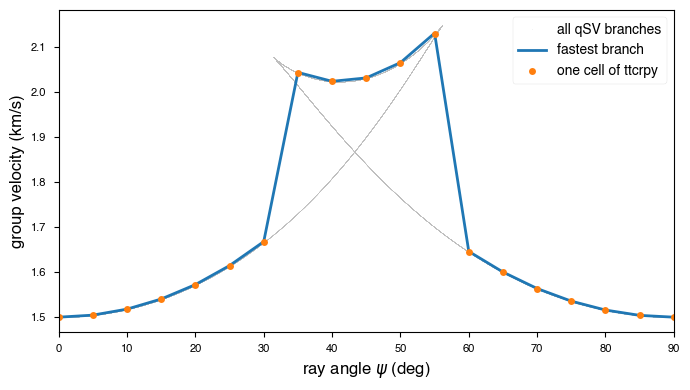

In [6]:
def fastest_branch(psi_query, psi, Vg, tol=2.0e-3):
    """largest of the branches sharing each ray angle"""
    return np.array([Vg[np.abs(np.angle(np.exp(1j*(psi - p)))) < tol].max()
                     for p in psi_query])


def one_cell_velocity(psi_deg, phase='qSV'):
    """group velocity ttcrpy uses for one straight segment"""
    out = []
    for p in np.radians(psi_deg):
        sx, sz = np.sin(p), np.cos(p)
        g = Grid2d(np.array([0.0, max(sx, 1e-6)]),
                   np.array([0.0, max(sz, 1e-6)]),
                   method='SPM', aniso='vti_psv', nsnx=0, nsnz=0,
                   tt_from_rp=False)
        g.set_Vp0(np.full(1, Vp0))
        g.set_Vs0(np.full(1, Vs0))
        g.set_epsilon(np.full(1, eps))
        g.set_delta(np.full(1, dlt))
        g.set_phase(phase)
        tt = g.raytrace(np.array([[0.0, 0.0]]), np.array([[sx, sz]]))[0]
        out.append(np.hypot(sx, sz)/tt)
    return np.array(out)


psi_deg = np.arange(0.0, 90.1, 5.0)
v_cell = one_cell_velocity(psi_deg)
v_true = fastest_branch(np.radians(psi_deg), psis, Vgs)

print('max relative difference from the fastest branch: '
      '{0:.1e}'.format(np.max(np.abs(v_cell - v_true)/v_true)))

plt.figure(figsize=(7, 4))
plt.plot(np.degrees(psis), Vgs, '.', ms=0.5, color='0.75',
         label='all qSV branches')
plt.plot(psi_deg, v_true, '-', lw=2, label='fastest branch')
plt.plot(psi_deg, v_cell, 'o', ms=5, label='one cell of ttcrpy')
plt.xlim(0, 90)
plt.xlabel(r'ray angle $\psi$ (deg)', fontsize=12)
plt.ylabel('group velocity (km/s)', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

### 6.4 What a whole model returns, and why it is not the same

Put the same medium on a grid, shoot from a point source, and the traveltimes
come back **faster** than the straight ray through the group velocity above —
by as much as 20 per cent.  That is not an error.  It is what a first arrival
is.

A wave is free to travel a bent path.  Splitting the journey between two
directions, a fraction of the time along each, reaches the point
$\alpha V_g(\psi_1)\mathbf{d}_1 + (1-\alpha) V_g(\psi_2)\mathbf{d}_2$ in unit
time, so **everything inside the convex hull of the wavefront is reachable**.
Where the wavefront is folded, a zig-zag beats the straight ray.

Straight down, for instance, the group velocity is exactly $V_{S0} = 1.5$ km/s,
so a direct ray covers 0.8 km in 0.533 s.  A ray leaving at $35^\circ$ travels
at 2.04 km/s and so gains depth at $2.04\cos 35^\circ = 1.67$ km/s, covering the
same 0.8 km in 0.478 s.  Zig-zagging at $\pm 35^\circ$ beats going straight, the
first arrival takes it, and the cusps never appear in the traveltime field.

(The qSV wave is quickest in absolute terms nearer $55^\circ$, at 2.13 km/s, but
that direction makes poorer downward progress.  What a zig-zag maximises is
$V_g(\psi)\cos\psi$, not $V_g$.)

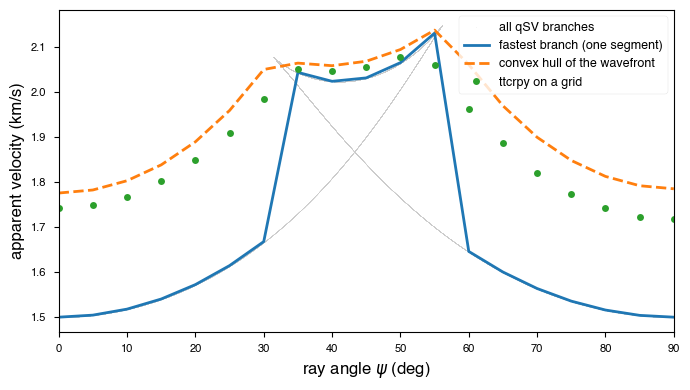

In [7]:
def convex_wavefront(psi_query, gx, gz, n=20001):
    """radius of the convex hull of the wavefront: the first arrival"""
    P = np.c_[gx, gz]
    an = np.linspace(0.0, 2.0*np.pi, n)
    N = np.c_[np.sin(an), np.cos(an)]
    h = (P @ N.T).max(axis=0)                 # support function
    D = np.c_[np.sin(psi_query), np.cos(psi_query)]
    nd = N @ D.T
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(nd > 1e-9, h[:, None]/nd, np.inf).min(axis=0)


def grid_velocity(h, nsn, r=0.8, phase='qSV'):
    x = np.arange(-1.0, 1.0 + 1e-9, h)
    g = Grid2d(x, x.copy(), method='SPM', aniso='vti_psv',
               nsnx=nsn, nsnz=nsn, tt_from_rp=False)
    nc = (x.size - 1)**2
    g.set_Vp0(np.full(nc, Vp0))
    g.set_Vs0(np.full(nc, Vs0))
    g.set_epsilon(np.full(nc, eps))
    g.set_delta(np.full(nc, dlt))
    g.set_phase(phase)
    q = np.radians(psi_deg)
    tt = g.raytrace(np.array([[0.0, 0.0]]), np.c_[r*np.sin(q), r*np.cos(q)])
    return r/tt


v_grid = grid_velocity(0.01, 10)
v_conv = convex_wavefront(np.radians(psi_deg), gxs, gzs)

plt.figure(figsize=(7, 4))
plt.plot(np.degrees(psis), Vgs, '.', ms=0.5, color='0.8',
         label='all qSV branches')
plt.plot(psi_deg, v_true, lw=2, label='fastest branch (one segment)')
plt.plot(psi_deg, v_conv, lw=2, ls='--', label='convex hull of the wavefront')
plt.plot(psi_deg, v_grid, 'o', ms=5, label='ttcrpy on a grid')
plt.xlim(0, 90)
plt.xlabel(r'ray angle $\psi$ (deg)', fontsize=12)
plt.ylabel('apparent velocity (km/s)', fontsize=12)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [8]:
# the grid result approaches the convex hull as the node graph is refined
print(' cell size   secondary nodes   max difference from the convex hull')
for h, nsn in ((0.02, 5), (0.01, 10), (0.01, 20), (0.005, 30)):
    vg = grid_velocity(h, nsn)
    rel = np.abs(vg - v_conv)/v_conv
    print('   {0:5.3f}          {1:3d}              {2:.1%}'.format(h, nsn, rel.max()))

 cell size   secondary nodes   max difference from the convex hull
   0.020            5              9.9%


   0.010           10              4.8%


   0.010           20              3.0%


   0.005           30              1.7%


### 6.5 The traveltime field

Finally the traveltime field itself, for qSV and for qP.  The qP wavefronts are
the smooth ovals its convex wavefront predicts.  The qSV wavefronts are visibly
**not** the folded curve of section 6.2: they are its convex hull, flattened
across the directions where the fold would have been.

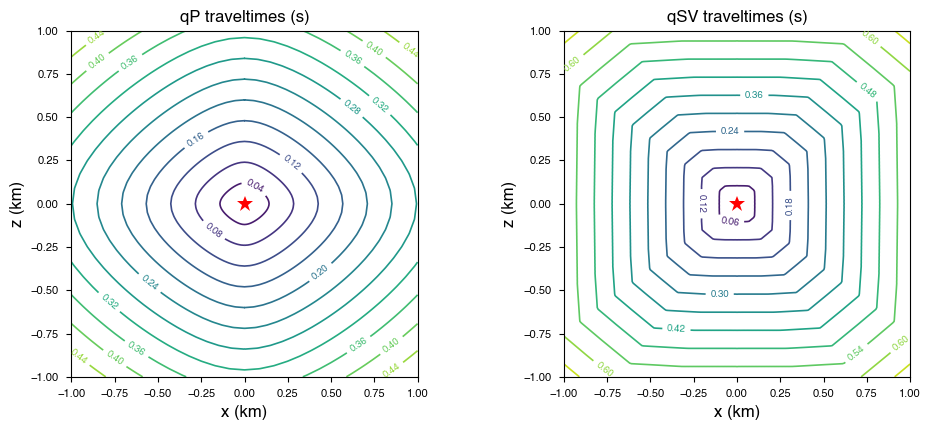

In [9]:
x = np.arange(-1.0, 1.0 + 1e-9, 0.01)
src = np.array([[0.0, 0.0]])
rcv = np.c_[np.kron(x, np.ones(x.size)), np.kron(np.ones(x.size), x)]

fig, ax = plt.subplots(1, 2, figsize=(10, 4.4))
for a, ph in zip(ax, ('qP', 'qSV')):
    g = Grid2d(x, x.copy(), method='SPM', aniso='vti_psv',
               nsnx=10, nsnz=10, tt_from_rp=False)
    nc = (x.size - 1)**2
    g.set_Vp0(np.full(nc, Vp0))
    g.set_Vs0(np.full(nc, Vs0))
    g.set_epsilon(np.full(nc, eps))
    g.set_delta(np.full(nc, dlt))
    g.set_phase(ph)
    tt = g.raytrace(src, rcv).reshape((x.size, x.size))
    cs = a.contour(x, x, tt.T, levels=12, linewidths=1.2)
    a.clabel(cs, inline=True, fontsize=7, fmt='%.2f')
    a.plot(0, 0, 'r*', ms=12)
    a.set_aspect('equal')
    a.set_xlabel('x (km)', fontsize=12)
    a.set_ylabel('z (km)', fontsize=12)
    a.set_title('{0} traveltimes (s)'.format(ph), fontsize=12)
plt.tight_layout()
plt.show()

### What to take away

- The qSV **group velocity** of a strongly anelliptic VTI medium is genuinely
  multivalued.  `ttcrpy` tabulates it and keeps the fastest branch, which
  section 6.3 checks to better than $10^{-3}$.
- The **traveltime field** of a first-arrival solver is nevertheless the convex
  hull of that wavefront.  The later branches of a triplication are not first
  arrivals anywhere, so no first-arrival method — shortest path, fast sweeping
  or fast marching — will produce them.  Recovering them needs a multivalued
  solver, which `ttcrpy` is not.
- This only bites where the wavefront actually folds.  Outside the cusp window,
  and for every qP model, the traveltimes follow the group velocity directly.

The parameters used here ($\sigma = 1.6$) were chosen to make the fold wide and
easy to see.  Triplication sets in well before that: the medium used in the
`ttcrpy` test suite, $V_{P0} = 3.094$, $V_{S0} = 1.51$, $\epsilon = 0.256$,
$\delta = -0.0505$, has $\sigma = 1.29$ and triplicates between $37^\circ$ and
$49^\circ$.

### References

- Thomsen, L., 1986. Weak elastic anisotropy. Geophysics, 51(10), 1954-1966.
  DOI : 10.1190/1.1442051
- Tsvankin, I., 2012. Seismic Signatures and Analysis of Reflection Data in
  Anisotropic Media, 3rd edition. Society of Exploration Geophysicists.